In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

In [8]:
df= pd.read_csv("marketing_campaign.csv", sep="\t")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [10]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [11]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [12]:
df["Age"]=2026- df["Year_Birth"]
spending_cols = ["MntWines" , "MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
df["TotalSpending"] = df[spending_cols].sum(axis=1)
df["TotalChildren"] =df["Kidhome"] + df["Teenhome"]

In [13]:
# Filtering
df = df[(df["Age"] >=18 )& (df["Age"] <=100)]
df=df[df["Income"] >0]


In [14]:
# Encoding
education_map ={ "Basic" :0, "Graduation":1, "Master":2, "PhD":3, "2n Cycle":1}
df["Education"]=df["Education"].map(education_map)
top_4_marital=df["Marital_Status"].value_counts().nlargest(4).index
df["Marital_Status"]=df["Marital_Status"].apply(lambda x:x if x in top_4_marital else "Other")
df = pd.get_dummies(df,columns=["Marital_Status"],drop_first=True)
df.head()

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Z_CostContact,Z_Revenue,Response,Age,TotalSpending,TotalChildren,Marital_Status_Married,Marital_Status_Other,Marital_Status_Single,Marital_Status_Together
0,5524,1957,1,58138.0,0,0,04-09-2012,58,635,88,...,3,11,1,69,1617,0,False,False,True,False
1,2174,1954,1,46344.0,1,1,08-03-2014,38,11,1,...,3,11,0,72,27,2,False,False,True,False
2,4141,1965,1,71613.0,0,0,21-08-2013,26,426,49,...,3,11,0,61,776,0,False,False,False,True
3,6182,1984,1,26646.0,1,0,10-02-2014,26,11,4,...,3,11,0,42,53,1,False,False,False,True
4,5324,1981,3,58293.0,1,0,19-01-2014,94,173,43,...,3,11,0,45,422,1,True,False,False,False


In [15]:
# =========================
# 6. Regression
# =========================

regression_features = [
    "Income",
    "Age",
    "TotalChildren",
    "Education",
    "Kidhome",
    "Teenhome",
    "Recency",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

X_reg = df[regression_features]
y_reg = df["TotalSpending"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

In [16]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=5, random_state=42)
}

regression_results = []

for name, model in regression_models.items():
    model.fit(X_train_reg_scaled, y_train_reg)
    y_pred = model.predict(X_test_reg_scaled)
    
    mse = mean_squared_error(y_test_reg, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_reg, y_pred)
    
    regression_results.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

regression_results_df = pd.DataFrame(regression_results)
regression_results_df

,Model,MSE,RMSE,R2 Score
0,Linear Regression,83735.236794,289.370415,0.779571
1,Ridge Regression,83719.786038,289.343716,0.779612
2,Decision Tree Regressor,53248.219298,230.755757,0.859827


In [17]:
# =========================
# 7. Classification
# =========================

df["Response"].value_counts()

Response
0    1903
1     334
Name: count, dtype: int64

In [18]:
df["Response"].value_counts(normalize=True) * 100

Response
0    85.069289
1    14.930711
Name: proportion, dtype: float64

In [19]:
classification_features = [
    "Income",
    "Age",
    "TotalChildren",
    "Education",
    "TotalSpending",
    "Kidhome",
    "Teenhome",
    "Recency",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

X_cls = df[classification_features]
y_cls = df["Response"]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

scaler_cls = StandardScaler()
X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

In [20]:
classification_models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

classification_results = []

for name, model in classification_models.items():
    
    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_cls_scaled, y_train_cls)
        y_pred = model.predict(X_test_cls_scaled)
    else:
        model.fit(X_train_cls, y_train_cls)
        y_pred = model.predict(X_test_cls)
    
    accuracy = accuracy_score(y_test_cls, y_pred)
    precision = precision_score(y_test_cls, y_pred)
    recall = recall_score(y_test_cls, y_pred)
    f1 = f1_score(y_test_cls, y_pred)
    
    classification_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })
    
    print("="*50)
    print(name)
    print("="*50)
    print(classification_report(y_test_cls, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_cls, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.75      0.84       381
           1       0.35      0.76      0.48        67

    accuracy                           0.75       448
   macro avg       0.65      0.75      0.66       448
weighted avg       0.86      0.75      0.78       448

Confusion Matrix:
[[285  96]
 [ 16  51]]
KNN
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       381
           1       0.54      0.19      0.29        67

    accuracy                           0.85       448
   macro avg       0.71      0.58      0.60       448
weighted avg       0.82      0.85      0.82       448

Confusion Matrix:
[[370  11]
 [ 54  13]]
Random Forest
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       381
           1       0.59      0.34      0.43        67

    accuracy                           0.87       448
   macro

In [21]:
classification_results_df = pd.DataFrame(classification_results)
classification_results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.750000,0.346939,0.761194,0.476636
1,KNN,0.854911,0.541667,0.194030,0.285714
2,Random Forest,0.866071,0.589744,0.343284,0.433962


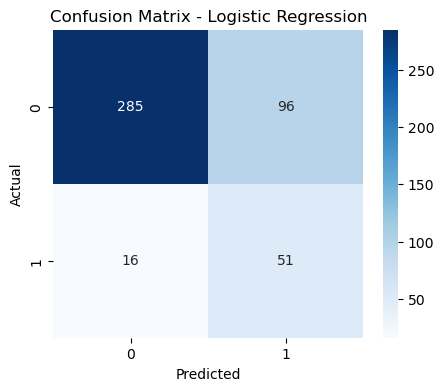

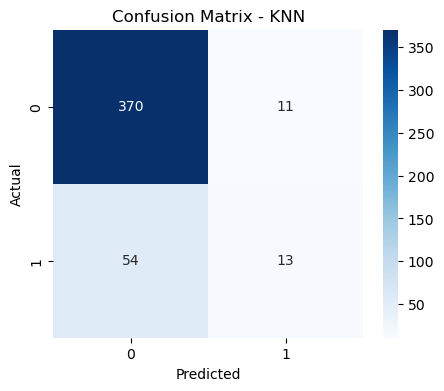

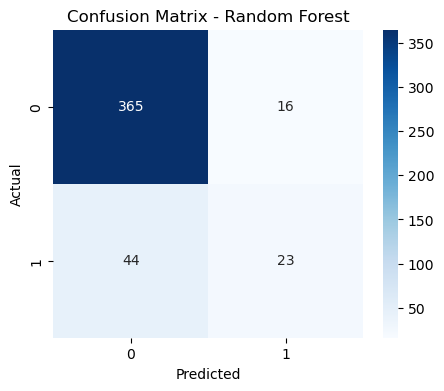

In [22]:
# Confusion Matrix Visualization

for name, model in classification_models.items():
    
    if name in ["Logistic Regression", "KNN"]:
        y_pred = model.predict(X_test_cls_scaled)
    else:
        y_pred = model.predict(X_test_cls)
    
    cm = confusion_matrix(y_test_cls, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [23]:
# =========================
# 8. Clustering
# =========================

cluster_features = ["TotalSpending", "Income", "Age", "TotalChildren"]

X_cluster = df[cluster_features]

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

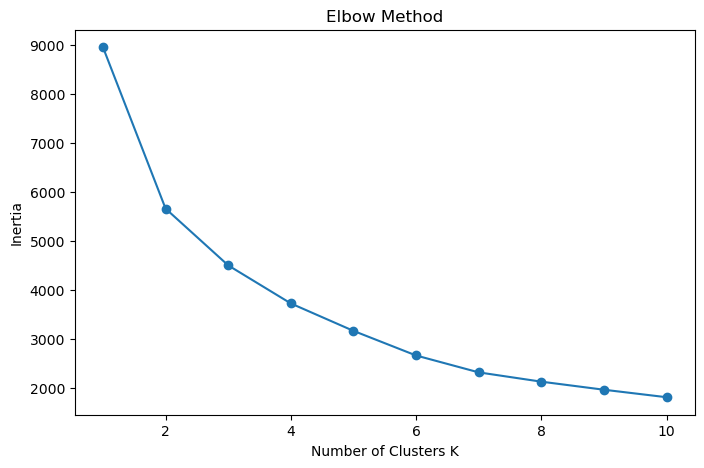

In [24]:
# Elbow Method

inertia_values = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia_values, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters K")
plt.ylabel("Inertia")
plt.show()

In [25]:
# Choose k = 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_cluster_scaled)

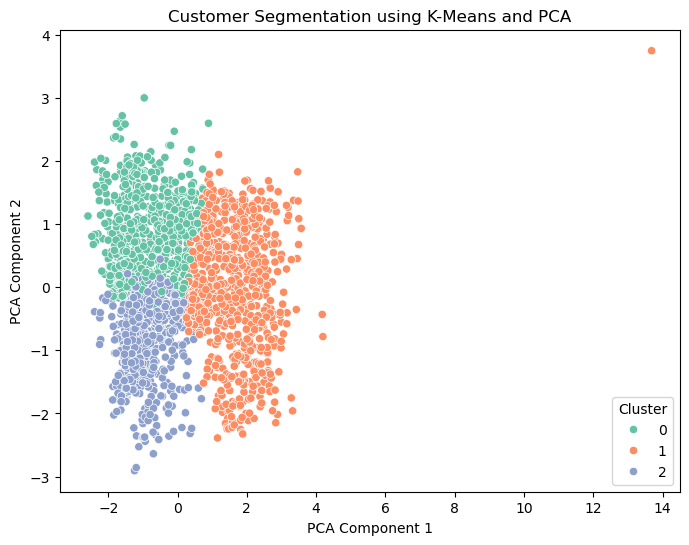

In [26]:
# PCA Visualization

pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_cluster_scaled)

df["PCA1"] = pca_components[:, 0]
df["PCA2"] = pca_components[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="Cluster", palette="Set2")
plt.title("Customer Segmentation using K-Means and PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [27]:
# Cluster Profiling

cluster_profile = df.groupby("Cluster")[cluster_features].mean()
cluster_profile

,TotalSpending,Income,Age,TotalChildren
Cluster,,,,
0,298.545070,47278.929577,63.940845,1.690141
1,1289.276382,74150.170854,58.640704,0.391960
2,159.804378,33161.607387,48.772914,0.841313


In [28]:
for cluster in cluster_profile.index:
    print(f"Cluster {cluster}:")
    print(cluster_profile.loc[cluster])
    print()

Cluster 0:
TotalSpending      298.545070
Income           47278.929577
Age                 63.940845
TotalChildren        1.690141
Name: 0, dtype: float64

Cluster 1:
TotalSpending     1289.276382
Income           74150.170854
Age                 58.640704
TotalChildren        0.391960
Name: 1, dtype: float64

Cluster 2:
TotalSpending      159.804378
Income           33161.607387
Age                 48.772914
TotalChildren        0.841313
Name: 2, dtype: float64



In [29]:
# Manual interpretation based on cluster profile table

for cluster in cluster_profile.index:
    income = cluster_profile.loc[cluster, "Income"]
    spending = cluster_profile.loc[cluster, "TotalSpending"]
    age = cluster_profile.loc[cluster, "Age"]
    children = cluster_profile.loc[cluster, "TotalChildren"]

    print(f"Cluster {cluster}:")
    
    if income > cluster_profile["Income"].mean() and spending > cluster_profile["TotalSpending"].mean():
        print("High-income, high-spending customers.")
    elif income < cluster_profile["Income"].mean() and spending < cluster_profile["TotalSpending"].mean():
        print("Low-income, low-spending customers.")
    else:
        print("Moderate-income or mixed-spending customers.")
    
    print()

Cluster 0:
Low-income, low-spending customers.

Cluster 1:
High-income, high-spending customers.

Cluster 2:
Low-income, low-spending customers.

